# Artificial Neural Networks (ANN)

This notebook implements **Artificial Neural Networks (ANNs)** as taught in **Stanford's CS229: Machine Learning (Autumn 2018)**:

- **Lecture 10 – Introduction to Neural Networks** *(Kian Katanforoosh)*
- **Lecture 11 – Backpropagation & Improving Neural Networks** *(Kian Katanforoosh)*

It includes:

- Fully Connected (**Dense**) neural network implementation
- Forward and Backpropagation from scratch
- Mini-batch Gradient Descent training
- Multiple activation functions:
  - Linear
  - Sigmoid
  - Tanh
  - ReLU
  - Leaky ReLU
  - Softplus
  - Softmax
- Multiple weight initialization methods:
  - Random Initialization
  - Xavier (Glorot) Initialization
  - He (Kaiming) Initialization
- Multiple optimization algorithms:
  - Stochastic Gradient Descent (SGD)
  - Adagrad
  - RMSprop
  - Adam
  - AdamW
- Multiple loss functions:
  - Mean Squared Error (MSE)
  - Binary Cross-Entropy (BCE)
  - Categorical Cross-Entropy (CCE)
- Dropout regularization
- Feature normalization using StandardScaler
- Train/Test data splitting
- Mini-batch generation
- Model persistence using compressed NumPy (`.npz`) files

> 📘 This notebook is part of the **ml-from-scratch** project, implementing machine learning and deep learning algorithms using only **NumPy** and **pandas** for educational purposes.

## Notebook Overview

This notebook presents **five practical implementations** of Artificial Neural Networks (ANNs), demonstrating how the same feedforward architecture can be adapted to solve different machine learning tasks.

The notebook includes:

1. **Regression**
   - Predicting medical insurance charges using the **Medical Cost Personal Dataset**.

2. **Binary Classification**
   - Diagnosing breast cancer using the **Breast Cancer Wisconsin Diagnostic (WDBC)** dataset.

3. **Multiclass Classification**
   - Recognizing handwritten digits (0–9) using the **MNIST** dataset.

4. **Deep Autoencoder**
   - Learning compact latent representations and reconstructing handwritten digit images from the **MNIST** dataset.

5. **Deep Denoising Autoencoder**
   - Reconstructing clean handwritten digits from noisy inputs using the **MNIST** dataset.

Throughout the notebook, the same neural network framework is reused with different architectures, activation functions, loss functions, and optimization algorithms to illustrate how Artificial Neural Networks can be applied across a wide range of supervised and unsupervised learning problems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optimizer import AdamW
from neural import NeuralNetwork
from activation import LeakyReLU, Linear, Sigmoid, Softmax
from layers import DenseLayer, DropoutLayer
from loss import MSE, BinaryCrossEntropy, CategoricalCrossEntropy
from data_loader import StandardScaler, train_test_split, get_mini_batches


## Regression Example: Insurance Charges Prediction

To demonstrate neural networks for regression, this notebook uses the **Medical Cost Personal Dataset (Insurance Dataset)**, a widely used benchmark for predicting individual medical insurance expenses.

The objective is to learn a non-linear mapping from demographic and lifestyle attributes to an individual's annual medical insurance charges.

### Dataset Overview

The Insurance dataset is a **tabular supervised learning dataset**, where each row represents an independent individual and there is no temporal or sequential relationship between observations. The prediction task is therefore a **static regression problem**, making it well suited for evaluating feedforward neural networks.

### Dataset Features

The dataset contains the following input features:

- **Age** – Age of the individual.
- **Sex** – Gender.
- **BMI** – Body Mass Index, an indicator of body fat based on height and weight.
- **Children** – Number of dependent children covered by insurance.
- **Smoker** – Smoking status.
- **Region** – Residential region within the United States (one-hot encoded).

The target variable is:

- **Charges** – Individual annual medical insurance cost.

### Why this Dataset?

Although relatively small, the Insurance dataset is a popular benchmark for regression because it contains both **continuous** and **categorical** variables while exhibiting strong **non-linear relationships**. In particular, smoking status has a significant impact on medical expenses, making the prediction task considerably more challenging than simple linear regression.

For a neural network, the dataset presents several practical challenges:

- Learning complex interactions between demographic and lifestyle features.
- Handling a mixture of continuous and categorical variables.
- Predicting a continuous target spanning a wide range of values.
- Generalizing well despite the relatively small number of training examples.

### Data Preprocessing

Before training:

- **Sex** and **Smoker** are encoded as binary variables.
- **Region** is represented using **one-hot encoding**.
- Both the input features and target variable (**Charges**) are standardized using **Z-score normalization**.
- The dataset is randomly divided into training and testing sets.

Standardizing both inputs and outputs improves optimization stability, allowing gradient-based optimization to converge more efficiently. Predictions are transformed back to the original dollar scale for evaluation.

The neural network is then trained using **backpropagation** to minimize the **Mean Squared Error (MSE)** between predicted and actual insurance charges.

### Model Performance

The trained network achieved a **Final Test Mean Absolute Error (MAE) of \$3,384.02**.

This means that, on average, the model's predicted insurance charge differs from the true medical insurance cost by approximately **\$3,384** per individual on the test set.

In [112]:
# Reads the insurance.csv file and converts text to numerical features.
# Features: age, sex, bmi, children, smoker, region.
# Target: charges.

In [130]:
with open("./data/insurance.csv", 'r') as f:
    lines = f.readlines()[1:]

x, y = [], []

region_map = {
    'northeast': [1.0, 0.0, 0.0, 0.0],
    'northwest': [0.0, 1.0, 0.0, 0.0],
    'southeast': [0.0, 0.0, 1.0, 0.0],
    'southwest': [0.0, 0.0, 0.0, 1.0]
}

for line in lines:
    row = line.strip().split(',')
    if len(row) < 7: 
        continue

    age = float(row[0])
    bmi = float(row[2])
    children = float(row[3])
    charges = float(row[6])

    sex = 1.0 if row[1] == 'male' else 0.0
    smoker = 1.0 if row[4] == 'yes' else 0.0

    region = region_map[row[5]]

    features = [age, sex, bmi, children, smoker] + region

    x.append(features)
    y.append([charges])

X, Y = np.array(x), np.array(y)



In [131]:
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")


X shape: (1338, 9)
Y shape: (1338, 1)


In [115]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [116]:
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_scaler = StandardScaler()
Y_train = y_scaler.fit_transform(Y_train)
Y_test = y_scaler.transform(Y_test)

In [117]:
model = NeuralNetwork(loss_fn=MSE())

In [118]:
model.add(DenseLayer(nin=9, nout=64, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.1))
    
model.add(DenseLayer(nin=64, nout=32, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.1))
    
model.add(DenseLayer(nin=32, nout=1, activation=Linear(), init_method="xavier"))

opt = AdamW(lr=0.005, weight_decay=0.01)

In [119]:
epochs = 30
batch_size = 64
history_train_loss = []
history_val_loss = []
    
print("\n--- Training Model ---")
model.train()
    
for epoch in range(epochs):
    model.train()
    batches = get_mini_batches(X_train, Y_train, batch_size)
    epoch_train_loss = 0.0
    for X_batch, Y_batch in batches:
        epoch_train_loss += model.train_step(X_batch, Y_batch, opt) * (X_batch.shape[0] / X_train.shape[0])
    
    model.eval()
    val_preds_scaled = model(X_test)
    epoch_val_loss = model.loss_fn(Y_test, val_preds_scaled)
    history_val_loss.append(epoch_val_loss)    

    history_train_loss.append(epoch_train_loss)        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

model.eval()


--- Training Model ---
Epoch 05/30 | Train Loss: 0.3163 | Val Loss: 0.2161
Epoch 10/30 | Train Loss: 0.2227 | Val Loss: 0.1967
Epoch 15/30 | Train Loss: 0.2120 | Val Loss: 0.1894
Epoch 20/30 | Train Loss: 0.1906 | Val Loss: 0.1941
Epoch 25/30 | Train Loss: 0.1654 | Val Loss: 0.1887
Epoch 30/30 | Train Loss: 0.1724 | Val Loss: 0.1790


In [120]:
test_preds_scaled = model(X_test)

test_preds_dollars = (test_preds_scaled * y_scaler.std) + y_scaler.mean
Y_test_dollars = (Y_test * y_scaler.std) + y_scaler.mean

mae = np.mean(np.abs(test_preds_dollars - Y_test_dollars))
print(f"\nFinal Test MAE: Your model is off by an average of ${mae:.2f} per person.")


Final Test MAE: Your model is off by an average of $3384.02 per person.


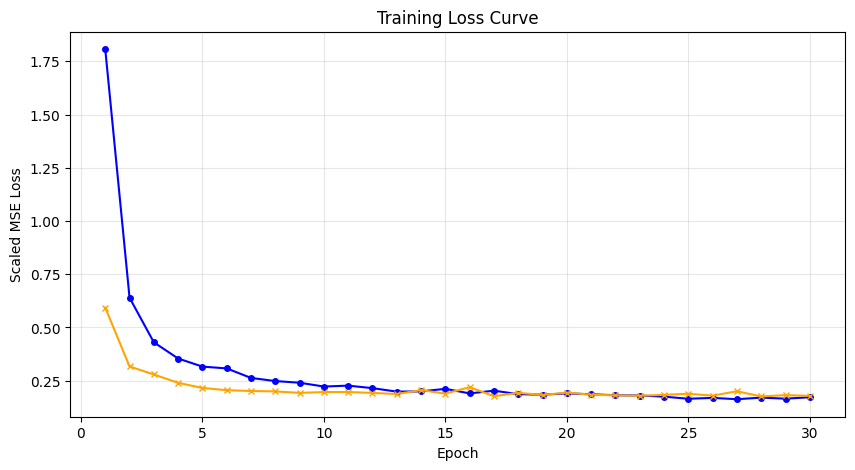

In [121]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), history_train_loss, label='Training Loss', marker='o', color='blue', markersize=4)
plt.plot(range(1, epochs + 1), history_val_loss, label='Validation Loss', marker='x', color='orange', markersize=4)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Scaled MSE Loss")
plt.grid(True, alpha=0.3)

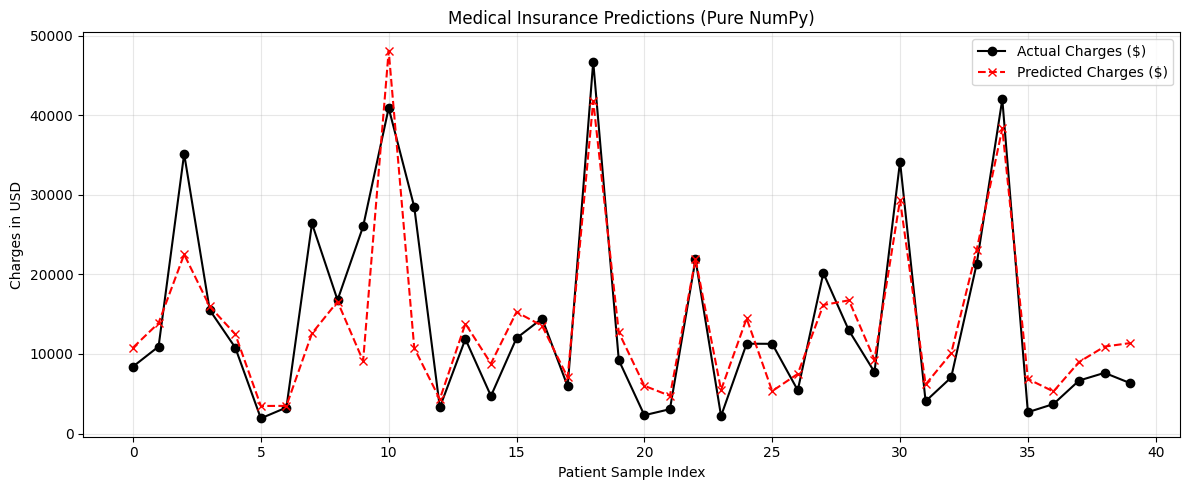

In [122]:
num_plot = 40
plt.figure(figsize=(12, 5))
plt.plot(Y_test_dollars[:num_plot], label="Actual Charges ($)", marker='o', color='black')
plt.plot(test_preds_dollars[:num_plot], label="Predicted Charges ($)", marker='x', linestyle='--', color='red')
    
plt.title("Medical Insurance Predictions (Pure NumPy)")
plt.ylabel("Charges in USD")
plt.xlabel("Patient Sample Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Binary Classification Example: Breast Cancer Diagnosis

To demonstrate neural networks for binary classification, this notebook uses the **Breast Cancer Wisconsin Diagnostic (WDBC)** dataset, a widely used benchmark for distinguishing between **malignant** and **benign** breast tumors.

The objective is to learn a non-linear decision boundary that accurately classifies a tumor based on measurements computed from digitized images of a **Fine Needle Aspirate (FNA)** of a breast mass.

### Dataset Overview

The WDBC dataset is a **tabular supervised learning dataset**, where each row represents an independent patient and there is no temporal or sequential relationship between observations. The task is a **binary classification problem**, making it well suited for feedforward neural networks.

The dataset contains **569 patient samples**, each described by **30 real-valued input features** extracted from cell nuclei in digitized breast mass images.

### Dataset Features

Each sample contains:

- **ID** – Unique patient identifier (discarded during training).
- **Diagnosis** – Target label:
  - **Malignant (M)** → 1
  - **Benign (B)** → 0
- **30 numerical features** describing characteristics of the cell nuclei, including:
  - Radius
  - Texture
  - Perimeter
  - Area
  - Smoothness
  - Compactness
  - Concavity
  - Concave Points
  - Symmetry
  - Fractal Dimension

For each characteristic, the dataset provides the **mean**, **standard error**, and **worst (largest)** observed value, resulting in a total of **30 input features**.

### Why this Dataset?

The WDBC dataset is one of the most widely used benchmark datasets for binary classification because it contains informative real-world medical features while remaining relatively small and well curated.

For a neural network, the dataset presents several practical challenges:

- Learning complex non-linear relationships between cellular measurements.
- Distinguishing subtle differences between malignant and benign tumors.
- Producing highly accurate predictions for a real-world medical diagnosis task.
- Generalizing well despite the relatively small number of training examples.

### Data Preprocessing

Before training:

- The patient **ID** is discarded.
- Diagnosis labels are encoded as **Malignant = 1** and **Benign = 0**.
- All numerical features are standardized using **Z-score normalization**.
- The dataset is randomly divided into training and testing sets.

The neural network is then trained using **backpropagation** to minimize the **Binary Cross-Entropy (BCE)** loss, with a **Sigmoid** activation function in the output layer to estimate the probability that a tumor is malignant.

### Model Performance

The trained neural network was evaluated on the held-out test set using standard binary classification metrics.

#### Final Evaluation

| Metric | Score |
|--------|------:|
| Accuracy | **97.37%** |
| Precision | **97.83%** |
| Recall (Sensitivity) | **95.74%** |
| F1 Score | **96.77%** |

The corresponding confusion matrix is:

| | Predicted Benign | Predicted Malignant |
|---|---:|---:|
| **Actual Benign** | **66** | **1** |
| **Actual Malignant** | **2** | **45** |

The model correctly classified **111 of the 114** test samples, achieving an overall **accuracy of 97.37%**.

A **precision of 97.83%** indicates that when the network predicts a tumor as malignant, it is correct nearly all of the time. A **recall of 95.74%** shows that the model successfully identifies the vast majority of malignant tumors while missing only a small number of positive cases. The resulting **F1 score of 96.77%** demonstrates an excellent balance between precision and recall, making the network well suited for this binary classification task.

In [ ]:
# Parses the standard wdbc.data file.
# Col 0: ID (Ignored)
# Col 1: Diagnosis (M = 1, B = 0)
# Col 2-31: 30 numerical features

In [28]:
with open("./data/wdbc.data", 'r') as f:
    lines = f.readlines()

x, y = [], []

for line in lines:
    row = line.strip().split(',')

    if len(row) < 32:
        continue

    label = 1.0 if row[1] == 'M' else 0.0

    features = [float(val) for val in row[2:]]

    x.append(features)
    y.append([label])

X, Y = np.array(x), np.array(y)

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

In [31]:
model = NeuralNetwork(loss_fn=BinaryCrossEntropy())

model.add(DenseLayer(nin=30, nout=64, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.3))
    
model.add(DenseLayer(nin=64, nout=32, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.3))
    
model.add(DenseLayer(nin=32, nout=1, activation=Sigmoid(), init_method="xavier"))

opt = AdamW(lr=0.001, weight_decay=0.05)

In [32]:
epochs = 40
batch_size = 32
    
history_train_loss = []
history_val_loss = []
    
print("\n--- Training Binary Classifier ---")

model.train()
for epoch in range(epochs):
    model.train() 
    batches = get_mini_batches(X_train, Y_train, batch_size)
    epoch_train_loss = 0.0
        
    for X_batch, Y_batch in batches:
        epoch_train_loss += model.train_step(X_batch, Y_batch, opt) * (X_batch.shape[0] / X_train.shape[0])
            
    history_train_loss.append(epoch_train_loss)
        
    model.eval() 
    val_preds_prob = model(X_test)
    epoch_val_loss = model.loss_fn(Y_test, val_preds_prob)
    history_val_loss.append(epoch_val_loss)
            
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train BCE: {epoch_train_loss:.4f} | Val BCE: {epoch_val_loss:.4f}")

model.eval()


--- Training Binary Classifier ---
Epoch 05/40 | Train BCE: 0.1550 | Val BCE: 0.1257
Epoch 10/40 | Train BCE: 0.0939 | Val BCE: 0.1124
Epoch 15/40 | Train BCE: 0.0839 | Val BCE: 0.1039
Epoch 20/40 | Train BCE: 0.0629 | Val BCE: 0.0980
Epoch 25/40 | Train BCE: 0.0530 | Val BCE: 0.0969
Epoch 30/40 | Train BCE: 0.0510 | Val BCE: 0.0969
Epoch 35/40 | Train BCE: 0.0326 | Val BCE: 0.0974
Epoch 40/40 | Train BCE: 0.0365 | Val BCE: 0.1029


In [33]:
print("\n--- Final Evaluation ---")
test_preds_prob = model(X_test)
test_preds_classes = (test_preds_prob >= 0.5).astype(float)

accuracy = np.mean(test_preds_classes == Y_test) * 100
print(f"Final Test Accuracy: {accuracy:.2f}%")


--- Final Evaluation ---
Final Test Accuracy: 97.37%


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_prob = model(X_test)

y_pred = (y_prob >= 0.5).astype(int)

accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)

print("--- Final Evaluation ---")
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1 Score : {f1:.2%}")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(Y_test, y_pred))

--- Final Evaluation ---
Accuracy : 97.37%
Precision: 97.83%
Recall   : 95.74%
F1 Score : 96.77%

Confusion Matrix
[[66  1]
 [ 2 45]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98        67
         1.0       0.98      0.96      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



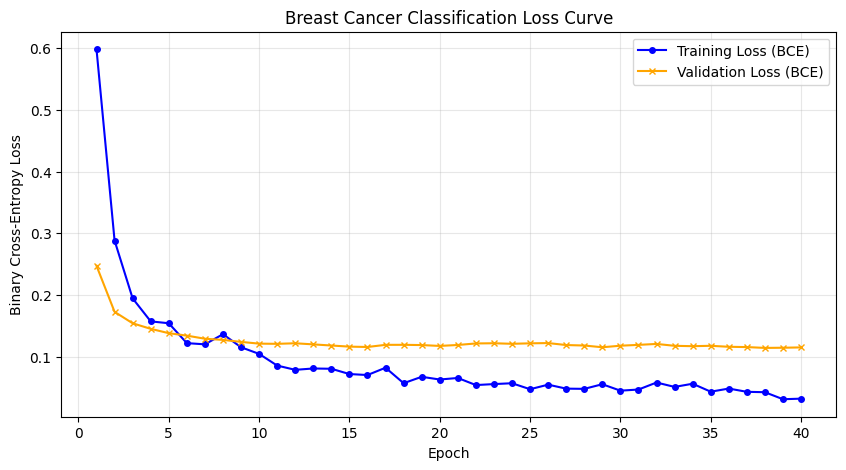

In [145]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), history_train_loss, label='Training Loss (BCE)', marker='o', color='blue', markersize=4)
plt.plot(range(1, epochs + 1), history_val_loss, label='Validation Loss (BCE)', marker='x', color='orange', markersize=4)
plt.title("Breast Cancer Classification Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [157]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

In [ ]:
def plot_pca_decision_boundary(model, X_scaled, Y_true):
    """Uses sklearn PCA to plot the true variance boundary of a 30D network."""
    plt.figure(figsize=(10, 6))
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    
    grid_30d = pca.inverse_transform(grid_2d)
    
    preds_prob = model(grid_30d)
    preds_classes = (preds_prob >= 0.5).astype(int)
    Z = preds_classes.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y_true.flatten(), cmap='bwr', edgecolors='k', s=30)
    
    plt.title("Neural Network Decision Boundary (via 2D PCA)")
    plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
    plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
    plt.show()

In [ ]:
def plot_3d_pca(X_scaled, Y_true):
    """Visualizes the patient data and a Linear Hyperplane in 3D PCA space."""

    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)
    
    svm = SVC(kernel='linear')
    svm.fit(X_pca, Y_true.flatten())
    
    w = svm.coef_[0]      
    b = svm.intercept_[0] 
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
               c=Y_true.flatten(), cmap='bwr', edgecolors='k', s=40, depthshade=True)
    
    xx, yy = np.meshgrid(np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 10),
                         np.linspace(X_pca[:, 1].min(), X_pca[:, 1].max(), 10))
    
    zz = -(w[0] * xx + w[1] * yy + b) / w[2]
    
    ax.plot_surface(xx, yy, zz, alpha=0.3, color='grey', edgecolor='none')
    
    ax.set_title("3D PCA Space with Linear SVM Hyperplane")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    plt.show()

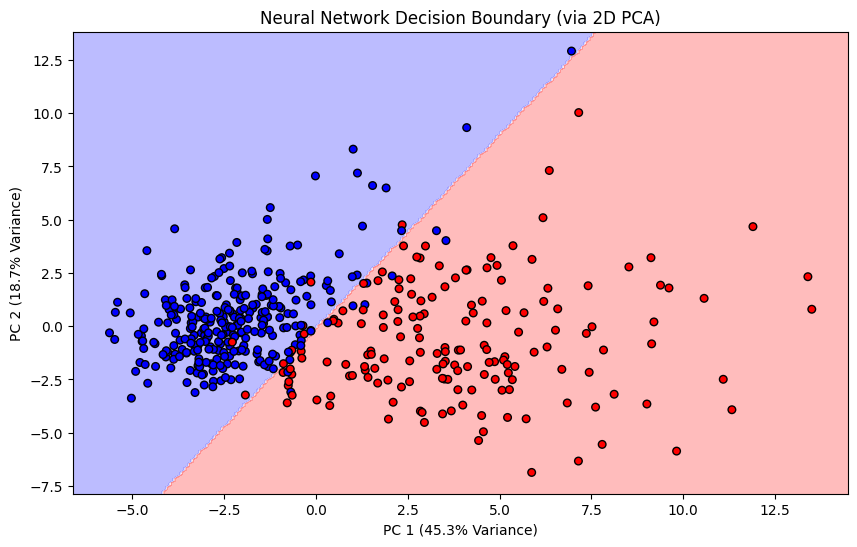

In [ ]:
plot_pca_decision_boundary(model, X_train, Y_train)


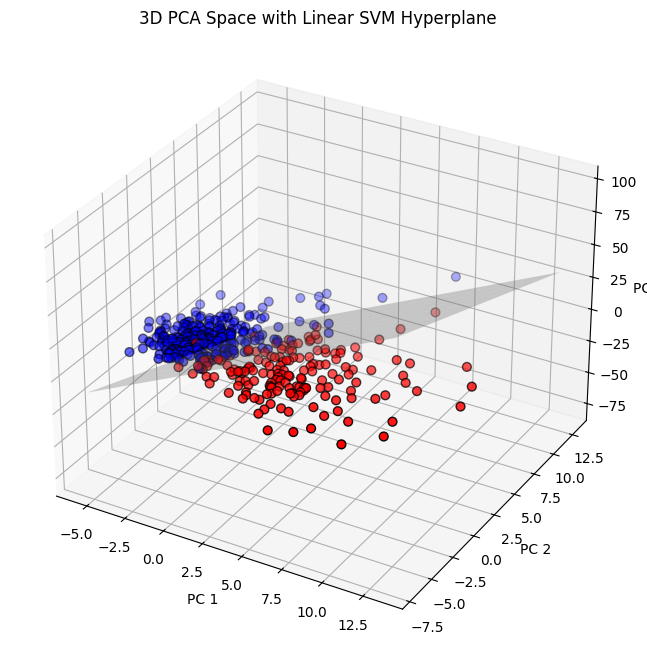

In [ ]:
plot_3d_pca(X_train, Y_train)

## Multiclass Classification Example: Handwritten Digit Recognition

To demonstrate neural networks for multiclass classification, this notebook uses the **MNIST Handwritten Digits** dataset, one of the most widely used benchmarks in machine learning and computer vision.

The objective is to classify grayscale images of handwritten digits into one of **ten classes (0–9)** using a feedforward neural network.

### Dataset Overview

MNIST is an **image classification dataset** consisting of grayscale handwritten digit images. Unlike tabular datasets, each sample is a **28 × 28 pixel image**, where neighboring pixels exhibit strong spatial relationships.

Although feedforward neural networks treat each pixel independently after flattening the image into a feature vector, MNIST remains an excellent benchmark for evaluating optimization algorithms, activation functions, and neural network architectures.

The dataset contains:

- **60,000** training images.
- **10,000** testing images.
- **10 balanced output classes** representing the digits **0–9**.

### Dataset Features

Each sample consists of:

- **784 input features**, corresponding to the pixel intensities of a **28 × 28** grayscale image.
- Pixel values range from **0 to 255**, where:
  - **0** represents a black pixel.
  - **255** represents a white pixel.

The target variable is:

- **Digit Label** – An integer from **0 to 9** representing the handwritten digit.

### Why this Dataset?

MNIST has served as the standard benchmark for image classification for decades because it is simple enough for rapid experimentation while still requiring the model to learn meaningful visual patterns.

For a feedforward neural network, the dataset presents several practical challenges:

- Learning discriminative representations directly from raw pixel values.
- Performing multiclass classification across ten output classes.
- Generalizing to handwriting styles not observed during training.
- Learning useful features despite the loss of spatial structure caused by flattening each image into a one-dimensional feature vector.

### Data Preprocessing

Before training:

- Pixel intensities are normalized from **[0, 255]** to **[0, 1]**.
- Class labels are converted into **one-hot encoded vectors**.
- Images are flattened into **784-dimensional feature vectors**.
- The provided training and testing splits are used throughout the experiments.

The neural network is then trained using **backpropagation** to minimize the **Categorical Cross-Entropy (CCE)** loss, with a **Softmax** output layer producing a probability distribution over the ten digit classes.

### Model Performance

The trained neural network was evaluated on the held-out **10,000-image** MNIST test set using standard multiclass classification metrics.

#### Final Evaluation

| Metric | Score |
|--------|------:|
| Accuracy | **98.05%** |
| Precision (Weighted) | **98.05%** |
| Recall (Weighted) | **98.05%** |
| F1 Score (Weighted) | **98.05%** |

The corresponding confusion matrix is shown below.

The model correctly classified **9,805 of the 10,000** test images, achieving an overall **accuracy of 98.05%**.

The weighted **precision (98.05%)** indicates that predictions across all ten digit classes are highly reliable, while the weighted **recall (98.05%)** shows that the network successfully identifies the vast majority of handwritten digits. The resulting **F1 score (98.05%)** demonstrates an excellent balance between precision and recall across all classes.

Inspection of the confusion matrix shows a strong **diagonal dominance**, indicating that most images are assigned to their correct classes. The relatively few misclassifications occur primarily between visually similar handwritten digits, including:

- **2 ↔ 7**
- **3 ↔ 5**
- **4 ↔ 9**

These errors are expected because such digit pairs often share similar handwritten shapes. Despite these challenging cases, the network generalizes well and achieves strong performance on this multiclass image classification benchmark.

In [ ]:
def load_mnist_csv(filepath: str):
    """
    Parses the MNIST CSV files.
    Column 0 is the label. Columns 1-784 are the pixels.
    """
    print(f"Loading {filepath} into memory (this might take a few seconds)...")
    
    data = np.loadtxt(filepath, delimiter=',')
    
    Y = data[:, 0]
    X = data[:, 1:]
    return X, Y

def one_hot_encode(Y: np.ndarray, num_classes=10) -> np.ndarray:
    """Converts a 1D array of labels (0-9) into a 2D One-Hot array."""
    one_hot = np.zeros((Y.shape[0], num_classes))
    one_hot[np.arange(Y.size), Y.astype(int)] = 1.0
    return one_hot

In [ ]:
X_train, Y_train = load_mnist_csv("./data/mnist_train.csv")
X_test, Y_test = load_mnist_csv("./data/mnist_test.csv")
    
X_train = X_train / 255.0
X_test = X_test / 255.0
    
Y_train_encoded = one_hot_encode(Y_train, num_classes=10)
Y_test_encoded = one_hot_encode(Y_test, num_classes=10)
    
print(f"Training Data Shape: {X_train.shape}")

Loading ./data/mnist_train.csv into memory (this might take a few seconds)...
Loading ./data/mnist_test.csv into memory (this might take a few seconds)...
Training Data Shape: (60000, 784)


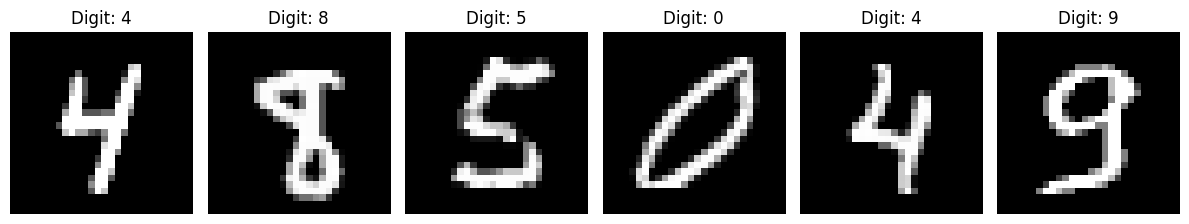

In [ ]:
def plot_mnist_samples(X, Y, num_samples=5):
    """Plots a row of random MNIST digits with their correct labels."""
    plt.figure(figsize=(num_samples * 2, 2.5))
    indices = np.random.choice(len(X), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        img = X[idx].reshape(28, 28)
        label = int(Y[idx])
        
        plt.subplot(1, num_samples, i + 1)
        
        plt.imshow(img, cmap='gray')
        plt.title(f"Digit: {label}")
        plt.axis('off')     
    plt.tight_layout()
    plt.show()

plot_mnist_samples(X_train, Y_train, num_samples=6)

In [40]:
model = NeuralNetwork(loss_fn=CategoricalCrossEntropy())

model.add(DenseLayer(nin=784, nout=128, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.2))
    
model.add(DenseLayer(nin=128, nout=64, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.2))
    
model.add(DenseLayer(nin=64, nout=10, activation=Softmax(), init_method="xavier"))

In [ ]:
opt = AdamW(lr=0.001, weight_decay=0.01)
    
    
epochs = 15  
batch_size = 128
    
history_train_loss = []
history_val_loss = []
        
for epoch in range(epochs):
    model.train() 
    batches = get_mini_batches(X_train, Y_train_encoded, batch_size)
    epoch_train_loss = 0.0

    for X_batch, Y_batch in batches:
        epoch_train_loss += model.train_step(X_batch, Y_batch, opt) * (X_batch.shape[0] / X_train.shape[0])
            
    history_train_loss.append(epoch_train_loss)
    model.eval() 
    val_preds_prob = model(X_test)

    epoch_val_loss = model.loss_fn(Y_test_encoded, val_preds_prob)
    history_val_loss.append(epoch_val_loss)
    pred_classes = np.argmax(val_preds_prob, axis=1)
    true_classes = np.argmax(Y_test_encoded, axis=1)
    val_acc = np.mean(pred_classes == true_classes) * 100
            
    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

print("\nTraining Complete!")

Epoch 01/15 | Train Loss: 0.4538 | Val Loss: 0.1641 | Val Accuracy: 94.89%
Epoch 02/15 | Train Loss: 0.1993 | Val Loss: 0.1214 | Val Accuracy: 96.34%
Epoch 03/15 | Train Loss: 0.1458 | Val Loss: 0.0940 | Val Accuracy: 97.06%
Epoch 04/15 | Train Loss: 0.1234 | Val Loss: 0.0889 | Val Accuracy: 97.17%
Epoch 05/15 | Train Loss: 0.1055 | Val Loss: 0.0809 | Val Accuracy: 97.45%
Epoch 06/15 | Train Loss: 0.0944 | Val Loss: 0.0711 | Val Accuracy: 97.91%
Epoch 07/15 | Train Loss: 0.0838 | Val Loss: 0.0762 | Val Accuracy: 97.67%
Epoch 08/15 | Train Loss: 0.0772 | Val Loss: 0.0760 | Val Accuracy: 97.77%
Epoch 09/15 | Train Loss: 0.0700 | Val Loss: 0.0732 | Val Accuracy: 97.70%
Epoch 10/15 | Train Loss: 0.0648 | Val Loss: 0.0709 | Val Accuracy: 97.91%
Epoch 11/15 | Train Loss: 0.0602 | Val Loss: 0.0736 | Val Accuracy: 97.87%
Epoch 12/15 | Train Loss: 0.0576 | Val Loss: 0.0687 | Val Accuracy: 98.01%
Epoch 13/15 | Train Loss: 0.0554 | Val Loss: 0.0684 | Val Accuracy: 98.07%
Epoch 14/15 | Train Loss:

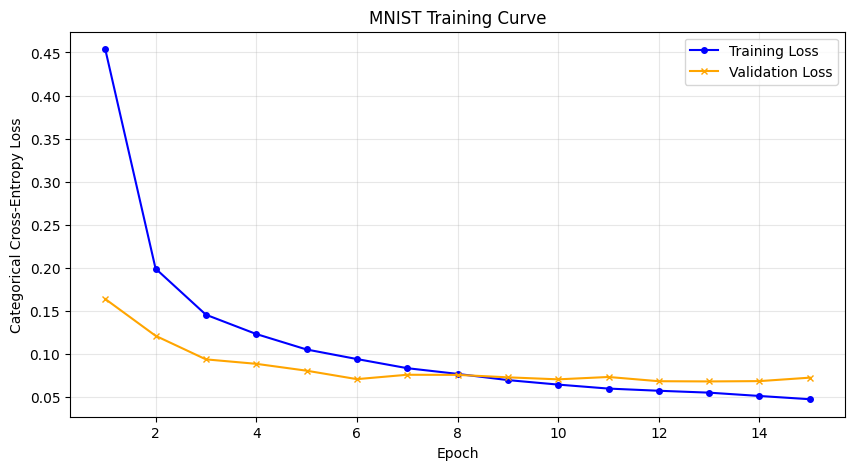

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), history_train_loss, label='Training Loss', marker='o', color='blue', markersize=4)
plt.plot(range(1, epochs + 1), history_val_loss, label='Validation Loss', marker='x', color='orange', markersize=4)
plt.title("MNIST Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def plot_model_predictions(model, X_test, Y_test_encoded, num_samples=6):
    """Plots test images with their True Labels vs the Model's Predictions."""
    plt.figure(figsize=(num_samples * 2.5, 3))

    indices = np.random.choice(len(X_test), num_samples, replace=False)
    X_sample = X_test[indices]
    Y_true_sample = Y_test_encoded[indices]
    model.eval()
    preds_prob = model(X_sample)
    pred_classes = np.argmax(preds_prob, axis=1)
    true_classes = np.argmax(Y_true_sample, axis=1)
    
    for i in range(num_samples):
        img = X_sample[i].reshape(28, 28)
        true_label = true_classes[i]
        pred_label = pred_classes[i]
        text_color = 'green' if true_label == pred_label else 'red'
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=text_color, fontweight='bold')
        plt.axis('off')    
    plt.tight_layout()
    plt.show()




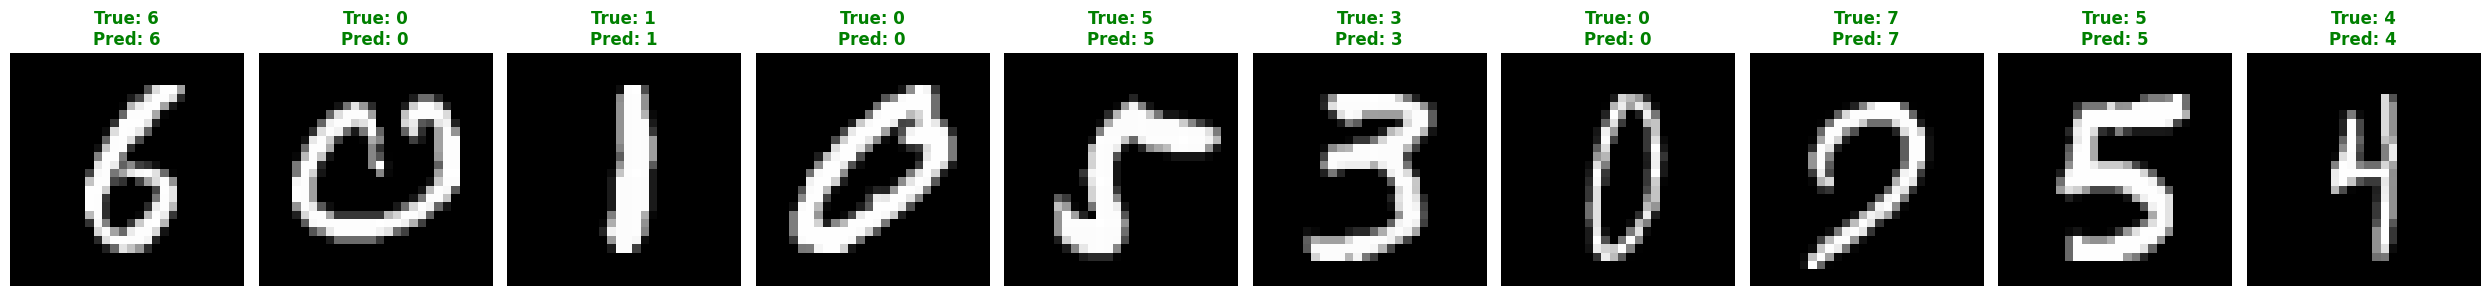

In [44]:
plot_model_predictions(model, X_test, Y_test_encoded, num_samples=10)

In [ ]:
model.eval()

y_prob = model(X_test)
y_pred = np.argmax(y_prob, axis=1)

y_true = np.argmax(Y_test_encoded, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
cm = confusion_matrix(y_true, y_pred)

print("--- Final Evaluation ---")
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1 Score : {f1:.2%}")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_true, y_pred))

--- Final Evaluation ---
Accuracy : 98.05%
Precision: 98.05%
Recall   : 98.05%
F1 Score : 98.05%

Confusion Matrix
[[ 971    1    2    1    0    1    2    1    1    0]
 [   0 1124    4    1    0    2    1    0    3    0]
 [   1    0 1019    1    1    0    1    5    4    0]
 [   0    0    5  990    0    4    0    4    2    5]
 [   1    0    5    1  961    0    5    1    2    6]
 [   2    0    0   10    0  869    5    1    4    1]
 [   1    3    2    1    4    2  944    0    1    0]
 [   2    2   11    2    1    0    0 1005    1    4]
 [   3    0    4    2    2    5    2    4  951    1]
 [   2    3    0    9   12    4    1    3    4  971]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
      

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

<Figure size 800x800 with 0 Axes>

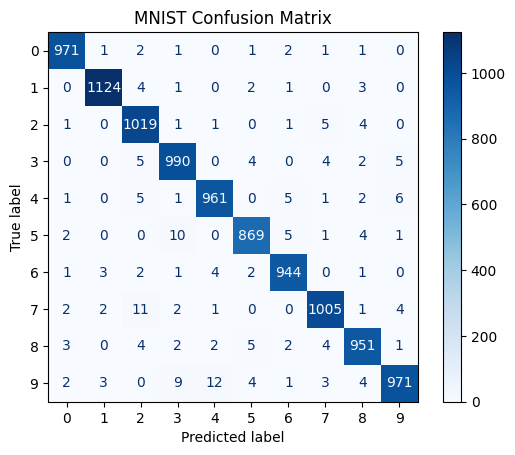

In [47]:
plt.figure(figsize=(8,8))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title("MNIST Confusion Matrix")
plt.show()

## Autoencoder Example: Image Reconstruction

To demonstrate unsupervised representation learning, this notebook implements a **Deep Autoencoder** trained on the **MNIST Handwritten Digits** dataset.

Unlike classification, the objective of an autoencoder is not to predict a class label but to reconstruct its input as accurately as possible after compressing it into a lower-dimensional latent representation.

### Dataset Overview

The MNIST dataset consists of grayscale handwritten digit images.

The dataset contains:

- **60,000** training images.
- **10,000** testing images.
- Images of size **28 × 28** pixels.

Each image is flattened into a **784-dimensional feature vector** before being passed through the neural network.

### Autoencoder Architecture

The encoder progressively compresses the input image:

```
784 → 256 → 128 → 64 → 32
```

The **32-neuron bottleneck** serves as the latent representation of the image.

The decoder reconstructs the image using a symmetric architecture:

```
32 → 64 → 128 → 256 → 784
```

The final layer uses a **Sigmoid** activation function to produce reconstructed pixel intensities in the range **[0,1]**.

### Why this Dataset?

MNIST is an ideal benchmark for autoencoders because handwritten digits contain rich visual structure while remaining computationally inexpensive.

The network must learn to:

- Compress high-dimensional images into a compact latent representation.
- Preserve the important structural characteristics of each digit.
- Reconstruct the original image with minimal information loss.
- Generalize to previously unseen handwritten digits.

### Data Preprocessing

Before training:

- Pixel intensities are normalized from **[0,255]** to **[0,1]**.
- Images are flattened into **784-dimensional vectors**.
- The network is trained to reconstruct its own input.

Training minimizes the **Mean Squared Error (MSE)** between the original image and its reconstruction using backpropagation.

### Model Performance

The trained autoencoder achieved the following reconstruction performance on the held-out test set.

#### Final Reconstruction Metrics

| Metric | Score |
|--------|------:|
| Mean Absolute Error (MAE) | **0.02399** |
| Pixel Reconstruction Accuracy | **92.09%** *(within 10% intensity tolerance)* |

The low reconstruction error indicates that the learned latent representation preserves most of the important visual information contained in the original images.

The training and validation loss curves decrease smoothly and converge to similar values, suggesting stable optimization with little evidence of overfitting.

Visual comparison between the original and reconstructed images further demonstrates that the network successfully captures the overall shape and structure of handwritten digits while introducing only minor smoothing artifacts, an expected characteristic of compressed latent representations.

In [21]:
model = NeuralNetwork(loss_fn=MSE())

model.add(DenseLayer(nin=784, nout=256, activation=LeakyReLU(), init_method="he"))
model.add(DenseLayer(nin=256, nout=128, activation=LeakyReLU(), init_method="he"))
model.add(DenseLayer(nin=128, nout=64,  activation=LeakyReLU(), init_method="he"))

model.add(DenseLayer(nin=64, nout=32, activation=Linear(), init_method="he"))
model.add(DenseLayer(nin=32, nout=64,  activation=LeakyReLU(), init_method="he"))

model.add(DenseLayer(nin=64, nout=128, activation=LeakyReLU(), init_method="he"))
model.add(DenseLayer(nin=128, nout=256, activation=LeakyReLU(), init_method="he"))
model.add(DenseLayer(nin=256, nout=784, activation=Sigmoid(), init_method="xavier"))

In [22]:
opt = AdamW(lr=0.001, weight_decay=0.01)
epochs = 25
batch_size = 128

history_train_loss = []
history_val_loss = []

for epoch in range(epochs):
    model.train()
    batches = get_mini_batches(X_train, X_train, batch_size) 
    epoch_train_loss = 0.0

    for X_batch, Target_batch in batches:
        epoch_train_loss += model.train_step(X_batch, Target_batch, opt) * (X_batch.shape[0] / X_train.shape[0])
    
    history_train_loss.append(epoch_train_loss)

    model.eval()
    val_reconstructions = model(X_test)

    epoch_val_loss = model.loss_fn(X_test, val_reconstructions)
    history_val_loss.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | Train MSE Loss: {epoch_train_loss:.5f} | Val MSE Loss: {epoch_val_loss:.5f}")

print("\n--- Autoencoder Training Complete! ---")


Epoch 01/25 | Train MSE Loss: 0.03438 | Val MSE Loss: 0.01852
Epoch 02/25 | Train MSE Loss: 0.01632 | Val MSE Loss: 0.01406
Epoch 03/25 | Train MSE Loss: 0.01322 | Val MSE Loss: 0.01197
Epoch 04/25 | Train MSE Loss: 0.01154 | Val MSE Loss: 0.01072
Epoch 05/25 | Train MSE Loss: 0.01042 | Val MSE Loss: 0.00990
Epoch 06/25 | Train MSE Loss: 0.00962 | Val MSE Loss: 0.00920
Epoch 07/25 | Train MSE Loss: 0.00902 | Val MSE Loss: 0.00868
Epoch 08/25 | Train MSE Loss: 0.00855 | Val MSE Loss: 0.00827
Epoch 09/25 | Train MSE Loss: 0.00815 | Val MSE Loss: 0.00790
Epoch 10/25 | Train MSE Loss: 0.00785 | Val MSE Loss: 0.00775
Epoch 11/25 | Train MSE Loss: 0.00757 | Val MSE Loss: 0.00757
Epoch 12/25 | Train MSE Loss: 0.00736 | Val MSE Loss: 0.00723
Epoch 13/25 | Train MSE Loss: 0.00717 | Val MSE Loss: 0.00720
Epoch 14/25 | Train MSE Loss: 0.00699 | Val MSE Loss: 0.00712
Epoch 15/25 | Train MSE Loss: 0.00684 | Val MSE Loss: 0.00697
Epoch 16/25 | Train MSE Loss: 0.00669 | Val MSE Loss: 0.00676
Epoch 17

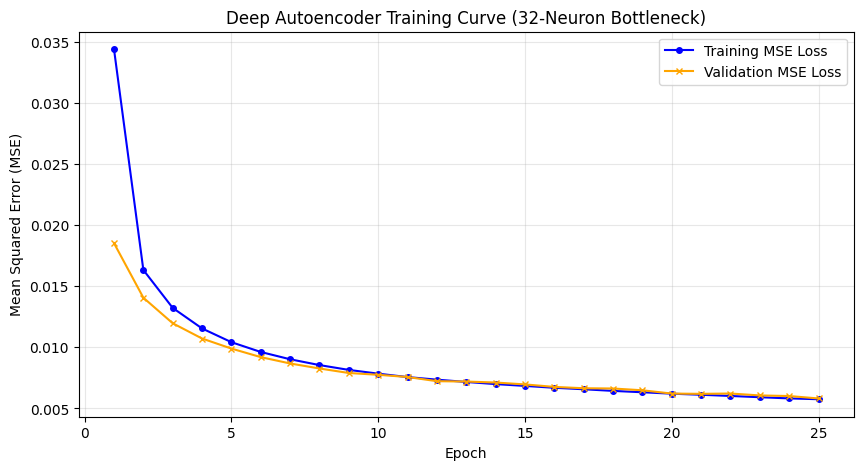

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), history_train_loss, label='Training MSE Loss', marker='o', color='blue', markersize=4)
plt.plot(range(1, epochs + 1), history_val_loss, label='Validation MSE Loss', marker='x', color='orange', markersize=4)
plt.title("Deep Autoencoder Training Curve (32-Neuron Bottleneck)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def plot_reconstructions(model, X_test, num_samples=8):
    """Visualizes original MNIST images vs their 8-neuron reconstructions."""
    plt.figure(figsize=(num_samples * 2, 4))
    
    indices = np.random.choice(len(X_test), num_samples, replace=False)
    X_original = X_test[indices]
    
    model.eval()
    X_reconstructed = model(X_original)
    
    for i in range(num_samples):

        plt.subplot(2, num_samples, i + 1)
        plt.imshow(X_original[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(X_reconstructed[i].reshape(28, 28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()



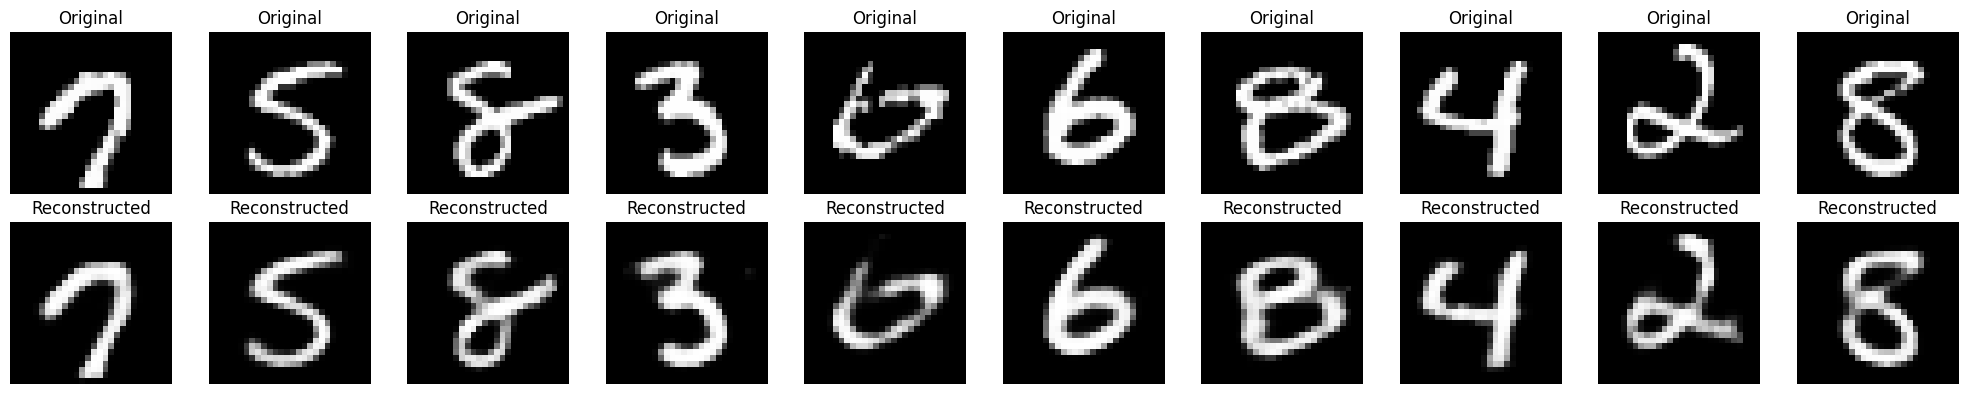

In [24]:
plot_reconstructions(model, X_test, num_samples=10)

In [ ]:
def print_reconstruction_metrics(model, X_test):
    """Calculates and prints the final reconstruction performance."""
    model.eval()
    reconstructed = model(X_test)
    mae = np.mean(np.abs(X_test - reconstructed))
    # Calculate 'Reconstruction Accuracy' (Percentage of pixels within a small threshold)
    # Let's say a pixel is 'correct' if it's within 0.1 (10% intensity) of the original
    threshold = 0.1
    pixel_accuracy = np.mean(np.abs(X_test - reconstructed) < threshold) * 100
    print(f"\n--- Final Reconstruction Metrics ---")
    print(f"Mean Absolute Error (MAE): {mae:.5f}")
    print(f"Pixel Reconstruction Accuracy: {pixel_accuracy:.2f}% (within {threshold*100}% tolerance)")



In [25]:
print_reconstruction_metrics(model, X_test)


--- Final Reconstruction Metrics ---
Mean Absolute Error (MAE): 0.02399
Pixel Reconstruction Accuracy: 92.09% (within 10.0% tolerance)


## Denoising Autoencoder Example

To demonstrate robust unsupervised representation learning, this notebook implements a **Deep Denoising Autoencoder** trained on the **MNIST Handwritten Digits** dataset.

Unlike a standard autoencoder, a denoising autoencoder receives a **corrupted version** of an image as input while learning to reconstruct the corresponding **clean image**. This encourages the network to learn meaningful latent representations instead of simply memorizing the input.

### Dataset Overview

The MNIST dataset consists of grayscale handwritten digit images.

The dataset contains:

- **60,000** training images.
- **10,000** testing images.
- Images of size **28 × 28** pixels.

Each image is flattened into a **784-dimensional feature vector** before being passed through the neural network.

### Noise Model

During training, the input images are artificially corrupted using two complementary noise processes:

- **Additive Gaussian Noise**, which perturbs pixel intensities with random values.
- **Masking Noise (Dropout Noise)**, where a fraction of input pixels is randomly set to zero.

The network therefore learns to recover the original clean digit from incomplete and noisy observations.

### Autoencoder Architecture

The encoder progressively compresses the noisy input:

```
784 → 256 → 128 → 64 → 32
```

The **32-neuron bottleneck** forms a compact latent representation.

The decoder reconstructs the clean image using a symmetric architecture:

```
32 → 64 → 128 → 256 → 784
```

The final layer uses a **Sigmoid** activation function to produce pixel values in the range **[0,1]**.

To further improve generalization, **Dropout** layers are included within the encoder and decoder.

### Why this Dataset?

MNIST provides an ideal benchmark for denoising because handwritten digits contain clear structural information while remaining computationally inexpensive.

The network must learn to:

- Remove random Gaussian noise.
- Recover pixels removed through masking.
- Preserve the identity and shape of each digit.
- Learn robust latent representations that generalize to unseen images.

### Data Preprocessing

Before training:

- Pixel intensities are normalized from **[0,255]** to **[0,1]**.
- Images are flattened into **784-dimensional vectors**.
- Random corruption is applied **only to the input images**.
- The reconstruction target always remains the corresponding **clean image**.

The network is trained using **backpropagation** to minimize the **Mean Squared Error (MSE)** between the reconstructed output and the original clean image.

### Model Performance

The trained denoising autoencoder was evaluated on the held-out MNIST test set.

#### Final Reconstruction Metrics

| Metric | Score |
|--------|------:|
| Mean Absolute Error (MAE) | **0.04022** |
| Pixel Reconstruction Accuracy | **88.25%** *(within 10% intensity tolerance)* |

The reconstruction metrics are computed by comparing the network's output against the **original clean test images**.

Visual inspection demonstrates that the network successfully removes much of the injected noise while preserving the overall shape and identity of the handwritten digits. Although some fine details are smoothed during reconstruction, the reconstructed images remain highly recognizable.

The training and validation loss curves decrease steadily throughout training, indicating stable optimization and effective learning of robust feature representations.

In [ ]:
def get_corrupted_input(X_batch, noise_std=0.1, drop_prob=0.2):
    """Combines Additive Noise and Masking Noise."""
    # Additive Noise
    X_noisy = X_batch + np.random.normal(loc=0.0, scale=noise_std, size=X_batch.shape)
    # Masking (Zero-Mask)
    mask = np.random.binomial(1, 1 - drop_prob, size=X_noisy.shape)
    return np.clip(X_noisy * mask, 0.0, 1.0)

In [ ]:
model = NeuralNetwork(loss_fn=MSE())

model.add(DenseLayer(nin=784, nout=256, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.2)) 

model.add(DenseLayer(nin=256, nout=128, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.2))

model.add(DenseLayer(nin=128, nout=64,  activation=LeakyReLU(), init_method="he"))

model.add(DenseLayer(nin=64, nout=32, activation=Linear(), init_method="he"))

model.add(DenseLayer(nin=32, nout=64,  activation=LeakyReLU(), init_method="he"))

model.add(DenseLayer(nin=64, nout=128, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.2)) 

model.add(DenseLayer(nin=128, nout=256, activation=LeakyReLU(), init_method="he"))
model.add(DropoutLayer(drop_rate=0.2))

model.add(DenseLayer(nin=256, nout=784, activation=Sigmoid(), init_method="xavier"))

In [12]:
opt = AdamW(lr=0.0005, weight_decay=0.001)
epochs = 100
batch_size = 128

history_train_loss = []
history_val_loss = []

for epoch in range(epochs):
    model.train()
    batches = get_mini_batches(X_train, X_train, batch_size) 
    epoch_train_loss = 0.0

    for X_batch, _ in batches:
        X_input = get_corrupted_input(X_batch)
        epoch_train_loss += model.train_step(X_input, X_batch, opt) * (X_batch.shape[0] / X_train.shape[0])
    
    history_train_loss.append(epoch_train_loss)

    model.eval()
    val_reconstructions = model(X_test)

    epoch_val_loss = model.loss_fn(X_test, val_reconstructions)
    history_val_loss.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | Train MSE Loss: {epoch_train_loss:.5f} | Val MSE Loss: {epoch_val_loss:.5f}")

print("\n--- Autoencoder Training Complete! ---")


Epoch 01/100 | Train MSE Loss: 0.05769 | Val MSE Loss: 0.03849
Epoch 02/100 | Train MSE Loss: 0.03682 | Val MSE Loss: 0.03596
Epoch 03/100 | Train MSE Loss: 0.03250 | Val MSE Loss: 0.03601
Epoch 04/100 | Train MSE Loss: 0.03007 | Val MSE Loss: 0.03554
Epoch 05/100 | Train MSE Loss: 0.02863 | Val MSE Loss: 0.03378
Epoch 06/100 | Train MSE Loss: 0.02766 | Val MSE Loss: 0.03329
Epoch 07/100 | Train MSE Loss: 0.02692 | Val MSE Loss: 0.03247
Epoch 08/100 | Train MSE Loss: 0.02633 | Val MSE Loss: 0.03213
Epoch 09/100 | Train MSE Loss: 0.02589 | Val MSE Loss: 0.03148
Epoch 10/100 | Train MSE Loss: 0.02549 | Val MSE Loss: 0.03001
Epoch 11/100 | Train MSE Loss: 0.02516 | Val MSE Loss: 0.03012
Epoch 12/100 | Train MSE Loss: 0.02488 | Val MSE Loss: 0.02747
Epoch 13/100 | Train MSE Loss: 0.02457 | Val MSE Loss: 0.02866
Epoch 14/100 | Train MSE Loss: 0.02440 | Val MSE Loss: 0.02869
Epoch 15/100 | Train MSE Loss: 0.02415 | Val MSE Loss: 0.02759
Epoch 16/100 | Train MSE Loss: 0.02396 | Val MSE Loss: 

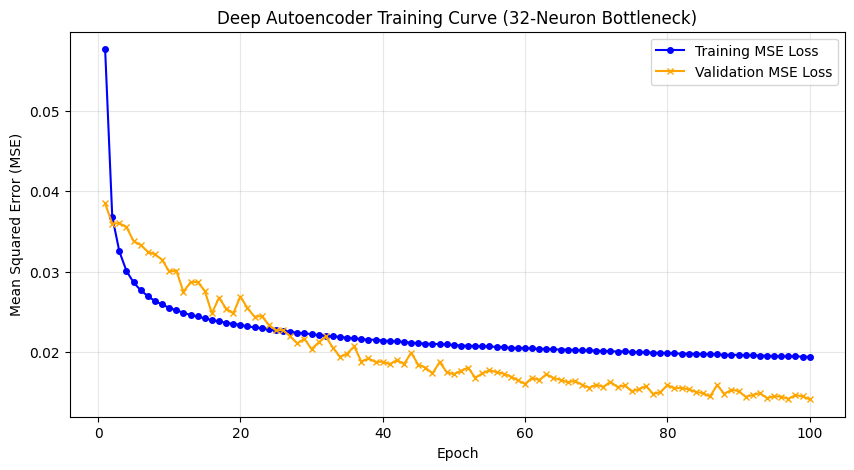

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), history_train_loss, label='Training MSE Loss', marker='o', color='blue', markersize=4)
plt.plot(range(1, epochs + 1), history_val_loss, label='Validation MSE Loss', marker='x', color='orange', markersize=4)
plt.title("Deep Autoencoder Training Curve (32-Neuron Bottleneck)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

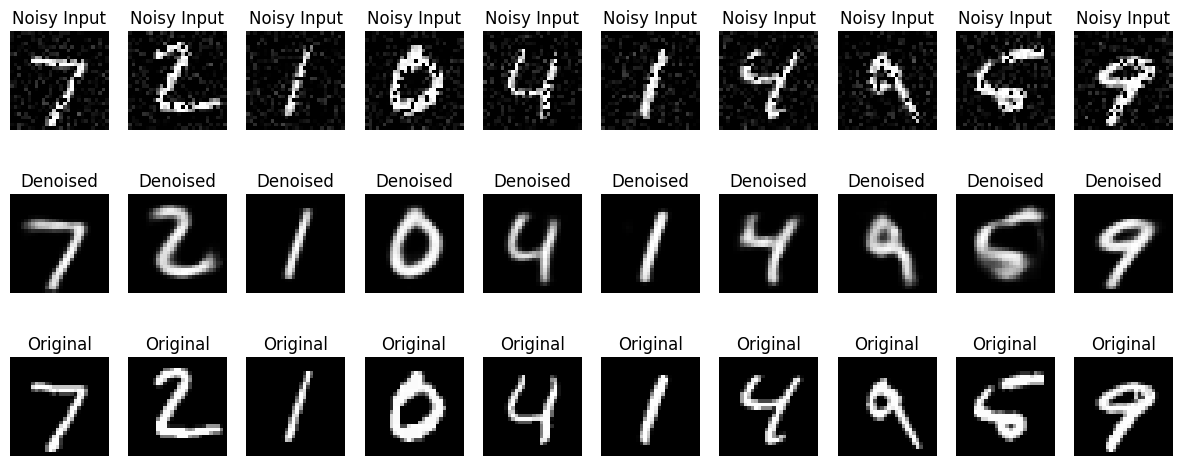

In [ ]:
def visualize_denoising(model, X_test, num_samples=10):
    model.eval()
    X_clean = X_test[:num_samples]
    X_noisy = get_corrupted_input(X_clean)
    X_denoised = model(X_noisy)
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):

        plt.subplot(3, num_samples, i + 1)
        plt.imshow(X_noisy[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Input")
        plt.axis('off')
        
        plt.subplot(3, num_samples, i + 1 + num_samples)
        plt.imshow(X_denoised[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')
        
        plt.subplot(3, num_samples, i + 1 + 2*num_samples)
        plt.imshow(X_clean[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')
    plt.show()

visualize_denoising(model, X_test)

In [15]:
model.save_model("model.npz")

Model successfully saved to model.npz


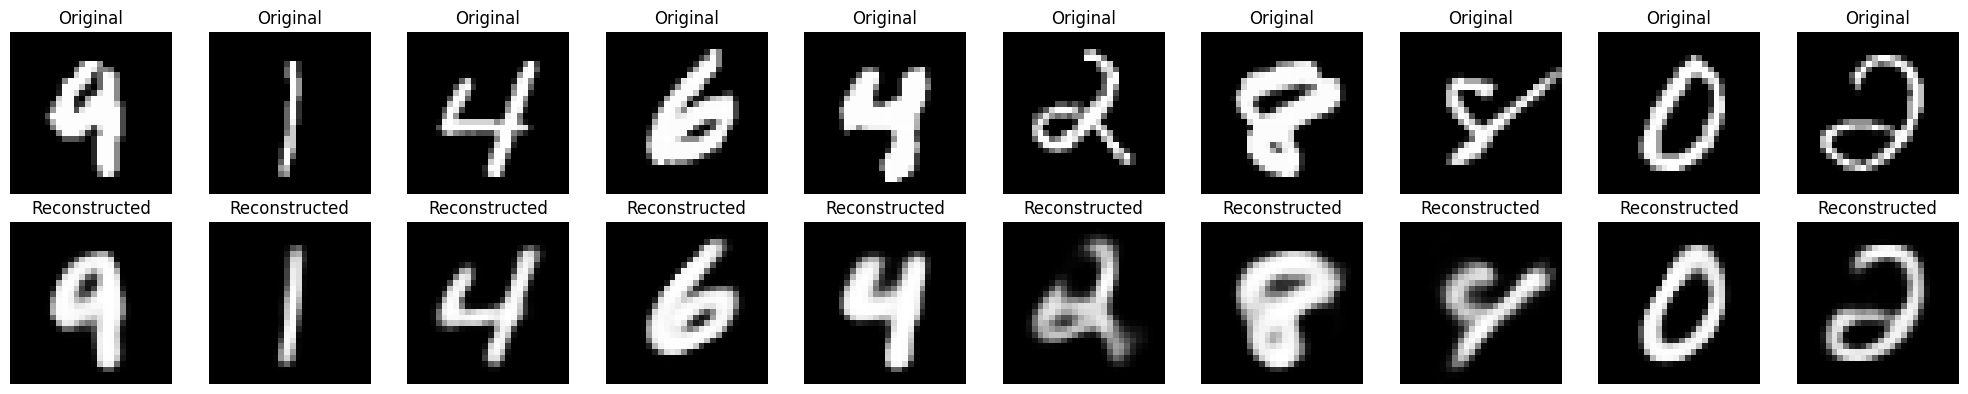

In [18]:
plot_reconstructions(model, X_test, num_samples=10)

In [20]:
print_reconstruction_metrics(model, X_test)


--- Final Reconstruction Metrics ---
Mean Absolute Error (MAE): 0.04022
Pixel Reconstruction Accuracy: 88.25% (within 10.0% tolerance)
